In [3]:
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd 
import datetime
import scipy
import torch
import tqdm
import xarray as xr

from cartopy.feature import LAND, BORDERS
from dantro.plot.utils import ColorManager
from pyproj import Transformer

# Local imports
import include as base

In [4]:
# Style settings
from matplotlib import rcParams
from cycler import cycler
colors = {
    
    'c_darkblue': '#2F7194',
    'c_red': '#ec7070',
    'c_darkgreen': '#48675A',
    'c_lightblue': '#97c3d0',
    'c_lightgreen': '#AFD8BC',
    'c_lightbrown': '#C6BFA2',
    'c_orange': '#EC9F7E',
    'c_yellow': '#F5DDA9',
    'c_darkgrey': '#3D4244',
    'c_pink': '#F8A6A6',
    'c_purple': '#A07CB0',
    'c_lightgrey': '#AFC1B9',
}
rcParams['axes.prop_cycle'] = cycler(color=list(colors.values()))
fs=9
rcParams.update(**{
    "text.usetex": True,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amssymb} \usepackage{amsmath}",
    "font.size": fs, 
    "axes.titlesize": fs,
    "axes.labelsize": fs,
    "xtick.labelsize": fs,
    "ytick.labelsize": fs,
    "legend.fontsize": fs,
    "grid.linewidth": 0.5,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    # "figure.dpi": 300
})
%matplotlib inline

---
# Load datasets
---

In [5]:
# Load the UN net migration data
UN_data = xr.load_dataset("../../data/Migration/UN_data.nc")

# Five-year bilateral flow estimates
five_year_estimates_comp = xr.open_dataset("../../data/Migration/bilateral_estimates.nc")

# Load the flow estimates from the stock data interpolation
flow_estimate = xr.load_dataarray("../../data/Migration/flow_estimates_from_stock_extended.nc")

# Net migration estimate from topology
estimated_net_migration = (flow_estimate.sum("Origin ISO").rename({"Destination ISO": "Country ISO"}) - flow_estimate.sum("Destination ISO").rename({"Origin ISO": "Country ISO"}))

# Conversion table for ISO3 codes
iso3_to_name = pd.read_csv("/Users/thomasgaskin/UN_migration_data/Iso_code_lookup.csv").set_index('Alpha-3 code')['Country'].to_dict()

# Country coordinates
country_coords = pd.read_csv("/Users/thomasgaskin/UN_migration_data/Coordinates.csv", index_col=2)
country_coords = country_coords[~country_coords.index.duplicated()]

---
# Convert to torch.tensor for training
---

In [6]:
# Convert the net migration to torch
YEAR_SEL = flow_estimate.coords["Year"].data
training_data = torch.from_numpy(
    UN_data['Net Number of Migrants (thousands)'].transpose('Year', ...).sel({'Year': YEAR_SEL}).data * 1000
).float()
N = training_data.shape[1]

# Convert the topology to torch
topology = torch.from_numpy(flow_estimate.data).float()

# Get the mask for the topology (edges which are all less or equal to 1) and apply to the topology
mask = torch.all(topology > 1, dim=0)
topology = torch.where(mask, topology, 0)

print(training_data.shape, topology.shape, mask.shape)

torch.Size([31, 236]) torch.Size([31, 236, 236]) torch.Size([236, 236])


---
# Setup and train the neural network
---

In [125]:
current_topology = torch.from_numpy(predicted_transport_plans.data)

In [126]:
# Minimum and maximum scaling of stock-based metric
min, max = 1, 2

In [127]:
NN = base.NeuralNet(
    input_size=N**2 + N,
    output_size=N**2,
    num_layers=5,
    nodes_per_layer=dict(default=60),
    activation_funcs=dict(default='sigmoid', layer_specific={-1: {'name': 'sigmoid', 'args': [max-min, 1, min]}}),
    biases=dict(default=None), 
    optimizer='Adam',
    learning_rate=0.002,
)

# Store training loss in array
loss_ts = []

In [128]:
# Set random seed from current date and time
np.random.seed(int(datetime.datetime.now().strftime('%m%d%H%M%S')))
torch.random.manual_seed(int(datetime.datetime.now().strftime('%m%d%H%M%S')))

# Number of epochs and batch size
num_epochs = 400
batch_size = 6

# Train
for it in (pbar:=tqdm.tqdm(range(num_epochs))):
    
    epoch_loss = []

    loss = torch.tensor(0.0, requires_grad=True)
    
    for j, dset in enumerate(training_data):

        # Make a prediction
        prediction =  NN(torch.concat([dset, torch.flatten(current_topology[j])])).reshape(N, N) * current_topology[j]
       # prediction = (prediction[:N].reshape(N, 1) * prediction[N:].reshape(1, N)) * topology[j]
        
        # Calculate the predicted net migration
        predicted_net_migration = torch.sum(prediction - torch.transpose(prediction, 0, 1), dim=0)
        
        # Match the net migration values
        data_loss = torch.nn.functional.mse_loss(predicted_net_migration, dset, reduction='sum') 
        
        # Set the trace to 0
        trace_loss = torch.trace(prediction)

        # Flows should sum to zero
        flow_loss = torch.abs(predicted_net_migration.sum())
        
        # Loss for this batch
        batch_loss = data_loss + flow_loss + trace_loss

        loss = loss + batch_loss
        
        # Gradient descent step
        if j % batch_size == 0 or j == training_data.shape[0] - 1:
            loss.backward()
            NN.optimizer.step()
            NN.optimizer.zero_grad()
            loss = torch.tensor(0.0, requires_grad=True)
        
        epoch_loss.append(batch_loss.detach().item())
    
    loss_ts.append(np.mean(epoch_loss).item())

    pbar.set_description_str(f"Current loss: {'{:g}'.format(loss_ts[-1])}")

Current loss: 1.33277e+12:  82%|████████▎ | 330/400 [01:14<00:15,  4.41it/s]


KeyboardInterrupt: 

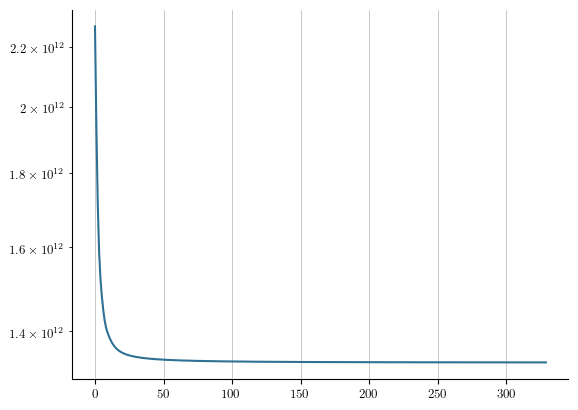

In [129]:
# Plot the loss
plt.plot(np.arange(len(loss_ts)), loss_ts)
plt.yscale('log')

In [130]:
# Get the predicted flows for each year
pred = []
for i in range(len(training_data)):
    _p = NN(torch.concat([training_data[i], current_topology[i].flatten()])).detach()
    # pred.append(
    #     _p[:N].reshape(N, 1) * _p[N:].reshape(1, N) * topology[i]
    # )
    pred.append(
        _p.reshape(N, N) * current_topology[i]
    )
predicted_transport_plans = xr.DataArray(
    torch.stack(pred), 
    dims=["Year", "Origin ISO", "Destination ISO"],
    coords={"Year": YEAR_SEL,
            "Origin ISO": UN_data.coords["Country ISO"].data, 
            "Destination ISO": UN_data.coords["Country ISO"].data}
)

# Get the predicted net migration for each year
predicted_net_migration = predicted_transport_plans.sum("Origin ISO").rename({"Destination ISO": "Country ISO"}) - predicted_transport_plans.sum("Destination ISO").rename({"Origin ISO": "Country ISO"})

In [108]:
# Get the correction factors
correction_factors = xr.DataArray(
    torch.stack([NN(torch.concat([training_data[i], current_topology[i].flatten()])).detach().reshape(N, N) for i in range(len(training_data))]),
    dims=["Year", "Origin ISO", "Destination ISO"],
    coords={"Year": YEAR_SEL,
            "Origin ISO": UN_data.coords["Country ISO"].data,
            "Destination ISO": UN_data.coords["Country ISO"].data}
)

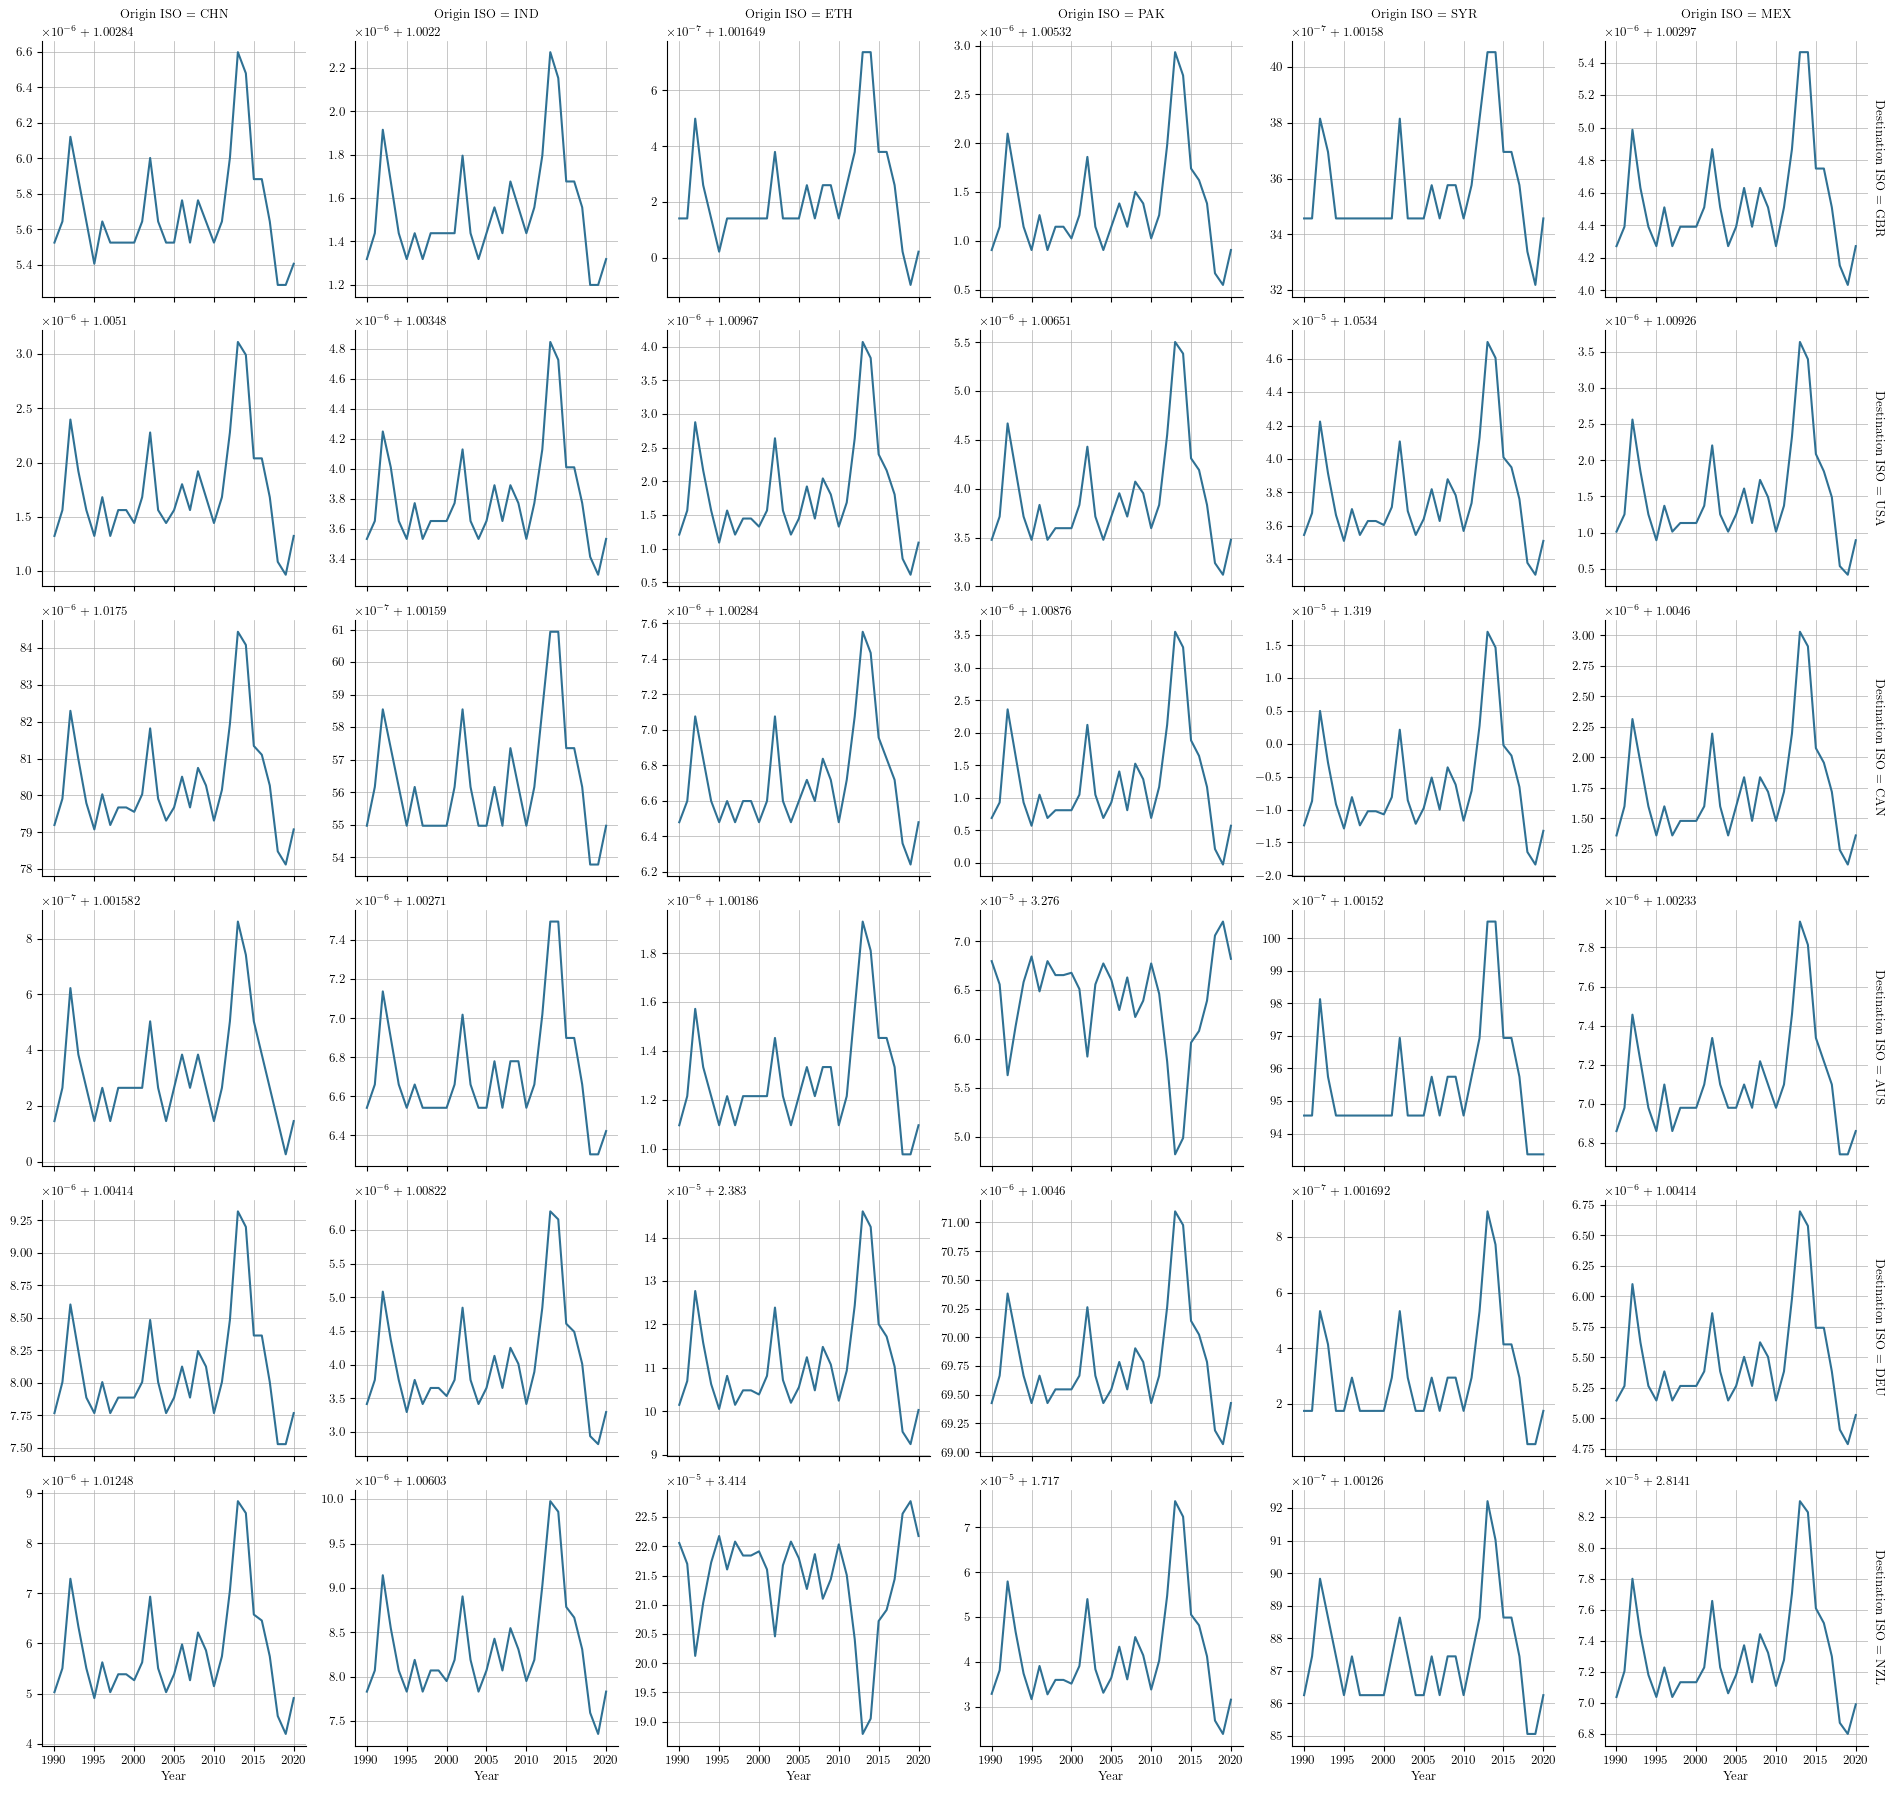

In [73]:
# Plot some correction factors
correction_factors.sel({"Origin ISO": ["CHN", "IND", "ETH", "PAK", "SYR", "MEX"], "Destination ISO": ["GBR", "USA", "CAN", "AUS", "DEU", "NZL"]}).plot(col="Origin ISO", row="Destination ISO", add_legend=False, sharey=False)

---
# Compare with UN net migration data
---

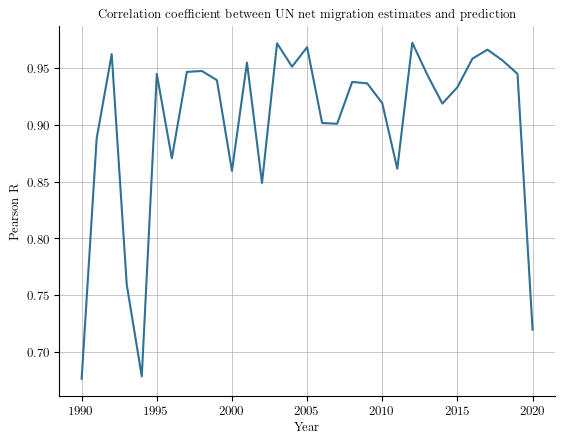

In [131]:
# Plot the Pearson R coefficient for all years
r_coeffs = []
for year in flow_estimate.coords["Year"].data:
    y = predicted_net_migration.sel({"Year": year})
    x = 1000 * UN_data["Net Number of Migrants (thousands)"].sel({"Country ISO": predicted_net_migration.coords["Country ISO"].data, "Year": year})
    r_coeffs.append(scipy.stats.pearsonr(x, y).statistic)

fig, ax = plt.subplots()
ax.plot(predicted_net_migration.coords["Year"].data, r_coeffs)
ax.set_ylabel("Pearson R")
ax.set_xlabel("Year")
ax.set_title("Correlation coefficient between UN net migration estimates and prediction");

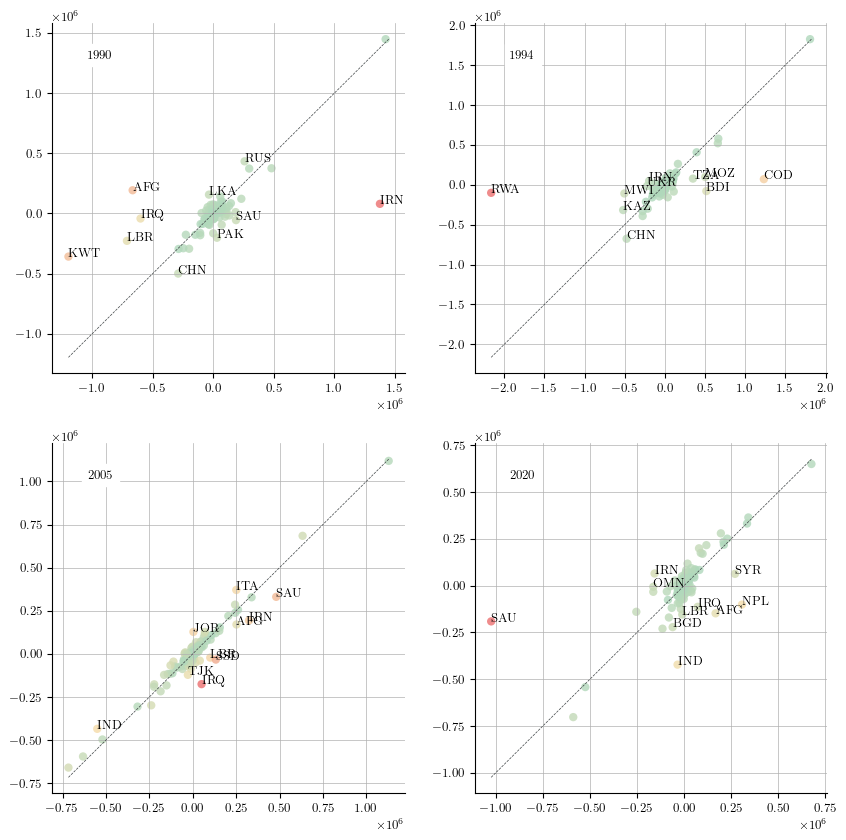

In [132]:
# Plot the correlation between UN migration rate and estimate for four years
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10, 10))

years = [1990, 1994, 2005, 2020]

for i, idx in enumerate(years):
    
    y = predicted_net_migration.sel({"Year": idx})
    x = 1000 * UN_data["Net Number of Migrants (thousands)"].sel({"Country ISO": predicted_net_migration.coords["Country ISO"].data, "Year": y.coords["Year"].data})

    color_data = abs(x-y)
    cm = ColorManager(
        cmap={'from_values': {0: colors['c_lightgreen'], 
                              0.5: colors['c_yellow'], 
                              1: colors['c_red']}, 
              'continuous': True},
        vmin=color_data.min(), vmax=color_data.max())   
    axs.flatten()[i].scatter(x, y, c=color_data, cmap=cm.cmap, alpha=0.8, lw=0)
    _min = np.minimum(x.min().item(), y.min().item())
    _max = np.maximum(x.max().item(), y.max().item())
    axs.flatten()[i].plot(
        [_min, _max], [_min, _max], lw=0.5, color=colors['c_darkgrey'], linestyle='dashed'
    )
    axs.flatten()[i].text(0.1, 0.9, f"{y.coords['Year'].data}", transform=axs.flatten()[i].transAxes, backgroundcolor='white')
    
    # Label the 5 largest discrepancies
    max_discrepancies = color_data.isel({"Country ISO": color_data.argsort().data[-10:]})
    for country in max_discrepancies.coords["Country ISO"].data:
        axs.flatten()[i].text(x.sel({"Country ISO": country}), y.sel({"Country ISO": country}), country)

In [91]:
five_year_estimates_comp['da_pb_closed'].sel({"Origin ISO": "RIN"})

array([ 87759.17, 318294.6 ,  94345.61, 171885.12, 127971.78, 146842.67])

---
# Compare with five-year flows
---

In [120]:
# Calculate 5-year estimates
five_year_estimates = []
for y in [1990, 1995, 2000, 2005, 2010, 2015]:
    five_year_estimates.append(
        predicted_transport_plans.sel({"Year": range(y, y+5)}).sum("Year")
    )
five_year_estimates = xr.concat(five_year_estimates, dim=pd.Index([1990, 1995, 2000, 2005, 2010, 2015], name="Year0"))

In [121]:
five_year_estimates_comp = xr.open_dataset("../../data/Migration/bilateral_estimates.nc")

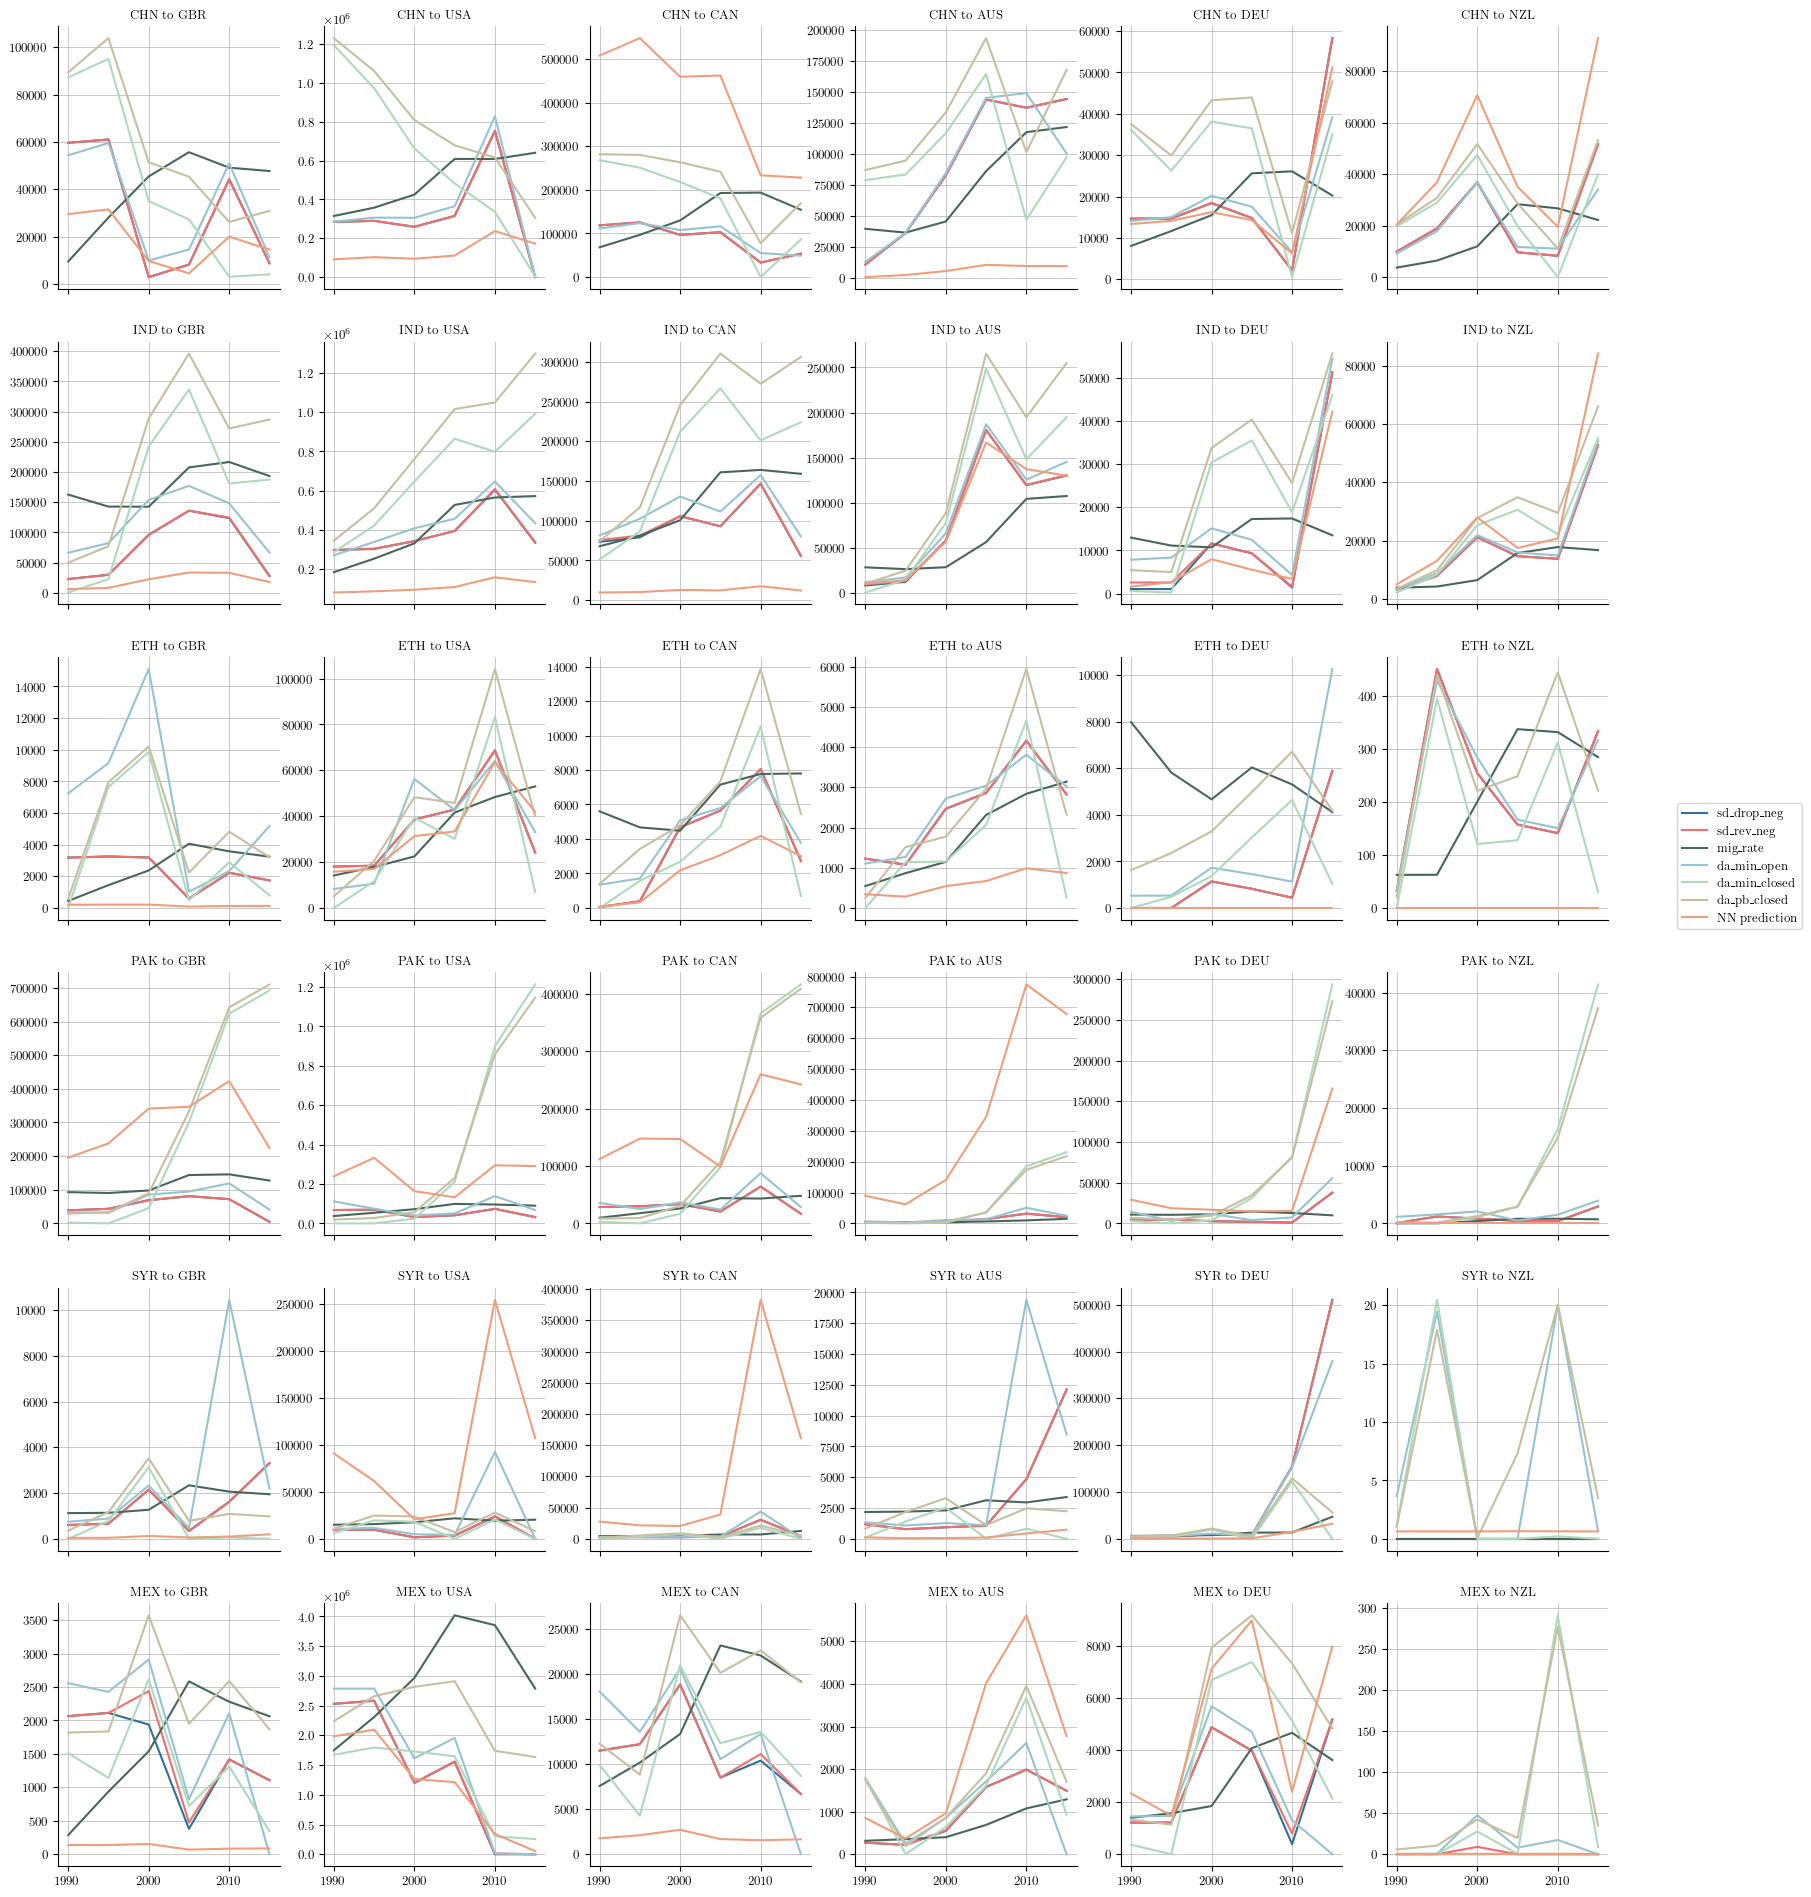

In [133]:
# Plot some predicted net migration values and compare with UN data
fig, axs = plt.subplots(ncols=6, nrows=6, figsize=(20, 20), sharex=True)
for i, o in enumerate(["CHN", "IND", "ETH", "PAK", "SYR", "MEX"]):
    for j, d in enumerate(["GBR", "USA", "CAN", "AUS", "DEU", "NZL"]):
        for var in list(five_year_estimates_comp.data_vars):
            five_year_estimates_comp[var].sel({"Origin ISO": o, "Destination ISO": d}).plot(ax=axs[i, j], label=var, add_legend=False)
        five_year_estimates.sel({"Origin ISO": o, "Destination ISO": d}).plot(ax=axs[i, j], label="NN prediction", add_legend=False)
        axs[i, j].set_title(f"{o} to {d}")
        axs[i, j].set_ylabel('')
        axs[i, j].set_xlabel('')

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.0, 0.5))
fig.subplots_adjust(wspace=0.2, hspace=0.2, top=0.92, bottom=0)

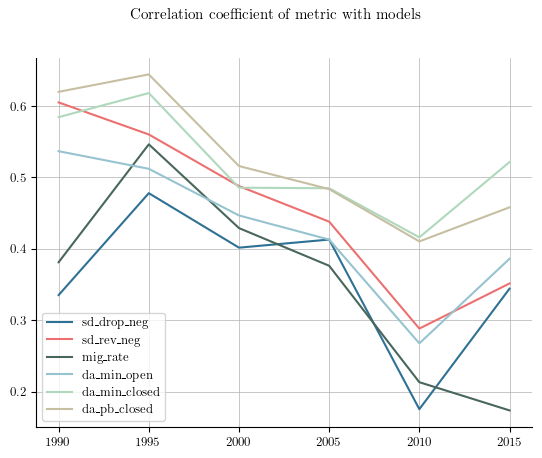

In [123]:
# Plot the correlation coefficient for each model over time
common_countries  = np.intersect1d(five_year_estimates.coords["Origin ISO"], five_year_estimates_comp.coords["Origin ISO"])
fig, ax = plt.subplots()
fig.suptitle("Correlation coefficient of metric with models")
for var in list(five_year_estimates_comp.data_vars):
    r_coeffs = []
    for year in five_year_estimates.coords["Year0"]:
        x = five_year_estimates.sel({"Year0": year, "Origin ISO": common_countries, "Destination ISO": common_countries}).data.flatten()
        y = five_year_estimates_comp[var].sel({"Year0": year, "Origin ISO": common_countries, "Destination ISO": common_countries}).data.flatten()
        msk = np.where(~np.isnan(y))
        r_coeffs.append(scipy.stats.pearsonr(x[msk], y[msk]).statistic)
    ax.plot(five_year_estimates.coords["Year0"], r_coeffs, label=var)
ax.legend();

NameError: name 'flow_estimate_extended' is not defined

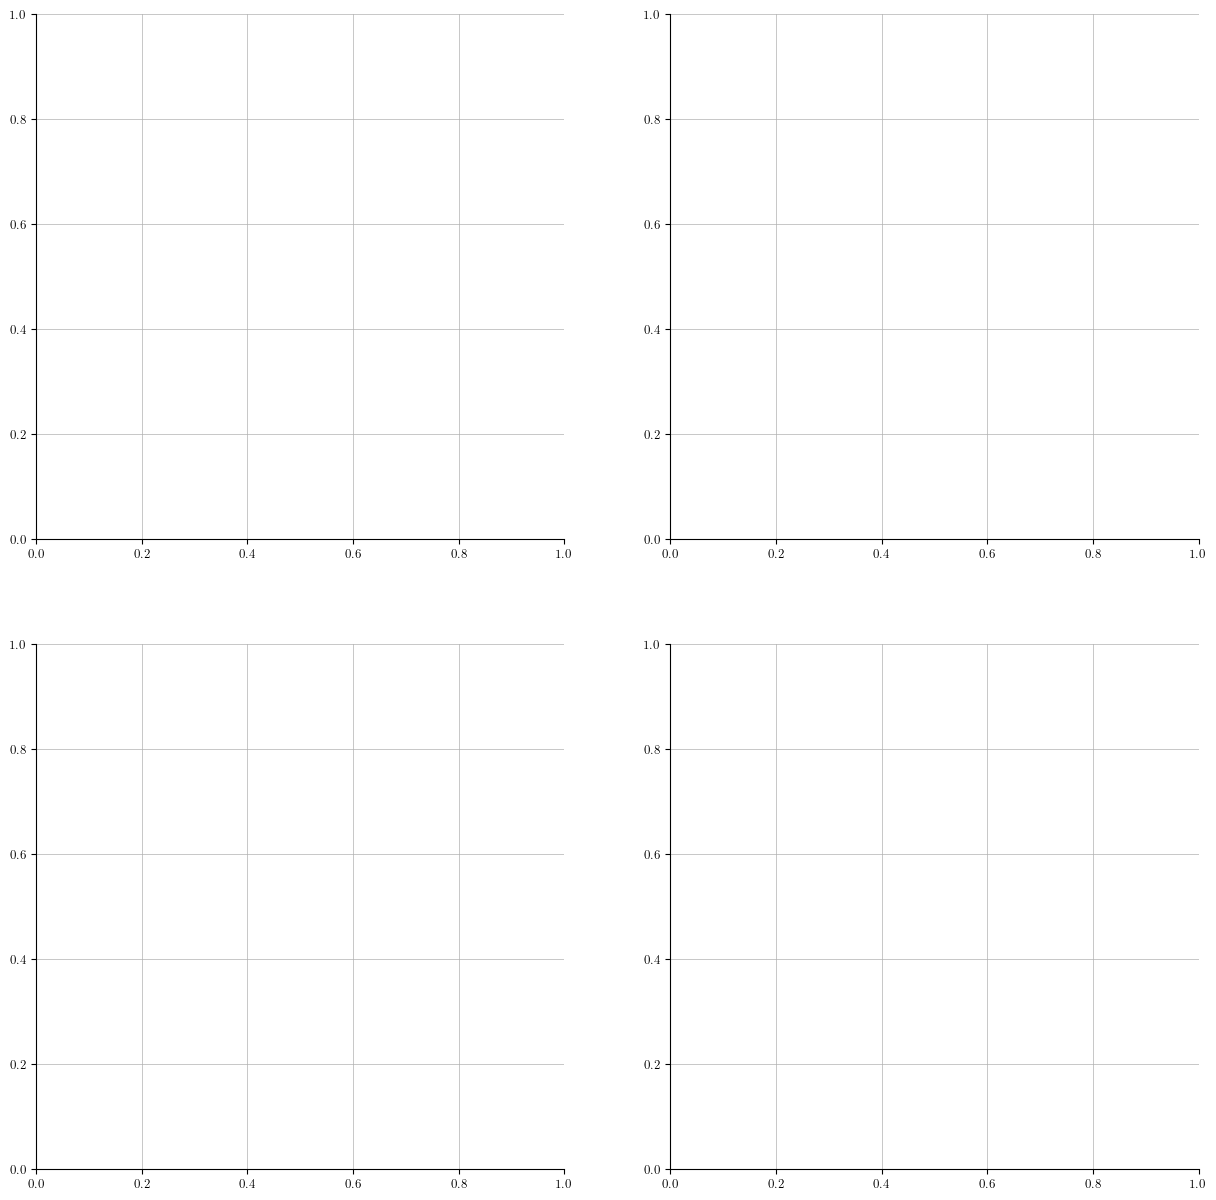

In [32]:
# Plot some flow values
org, des = ["CHN", "IND"], ["CAN", "USA"]
fig, axs = plt.subplots(ncols=len(org), nrows=len(des), sharey=False, figsize=(15, 15))
for i, o in enumerate(org):
    for j, d in enumerate(des):
        flow_estimate_extended.sel({"Origin ISO": o, "Destination ISO": d}).plot.line(ax=axs[i, j], label='Estimate')
        predicted_transport_plans.sel({"Origin ISO": o, "Destination ISO": d}).plot.line(ax=axs[i, j], label='Prediction')
        # fb_data.sel({"Origin ISO": o, "Destination ISO": d}).plot.scatter(ax=axs[i, j], c='red', label='Facebook data')
        axs[i, j].legend()

Text(0.5, 1.0, 'Prediction')

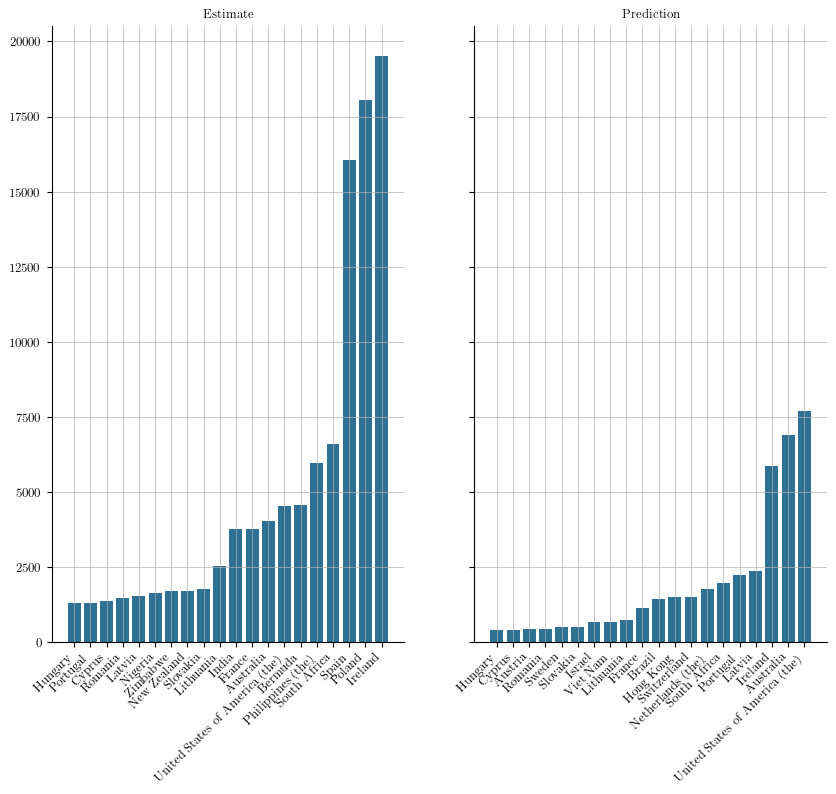

In [215]:
fig, axs = plt.subplots(ncols=2, figsize=(10, 8), sharey=True)
y, x = "Destination ISO", "Origin ISO"
_ex = flow_estimate_extended.sel({"Year": 2000, x: "GBR"}, drop=True)
_ex = _ex.isel({y: _ex.argsort().data[-20:]})
axs[0].bar(_ex.coords[y], _ex)
_ = axs[0].set_xticks(_ex.coords[y].data, [iso3_to_name.get(c, c) for c in _ex.coords[y].data], rotation=45, ha='right')
axs[0].set_title("Estimate")

_ex = predicted_transport_plans.sel({"Year": 2000, x: "GBR"}, drop=True)
_ex = _ex.isel({y: _ex.argsort().data[-20:]})
axs[1].bar(_ex.coords[y], _ex)
_ = axs[1].set_xticks(_ex.coords[y].data, [iso3_to_name.get(c, c) for c in _ex.coords[y].data], rotation=45, ha='right')
axs[1].set_title("Prediction")

In [0]:
fig, axs = plt.subplots(ncols=2, nrows=4, figsize=(10, 16))
fig.subplots_adjust(hspace=0.5)
for idx, country in enumerate(["USA", "AUS", "GBR", "FRA"]):
    ex_data = predicted_transport_plans.sel({"Destination ISO": country}, drop=True)
    ex_data = ex_data.isel({"Origin ISO": ex_data.mean("Year").argsort().data[-4:]})
    _ = ex_data.plot.line(hue="Origin ISO", ax=axs[idx, 0])
    axs[idx, 0].set_title(country)
    axs[idx, 0].set_xlabel('')

for idx, country in enumerate(["IND", "CHN", "RUS", "PHL"]):
    ex_data = predicted_transport_plans.sel({"Origin ISO": country}, drop=True)
    ex_data = ex_data.isel({"Destination ISO": ex_data.mean("Year").argsort().data[-4:]})
    _ = ex_data.plot.line(hue="Destination ISO", ax=axs[idx, 1])
    axs[idx, 1].set_title(country)
    axs[idx, 1].set_xlabel('')

In [0]:
# Total volume of migration flow
fig, axs = plt.subplots(ncols=2, figsize=(20, 4))
_ = predicted_transport_plans.sum(['source']).plot.line(hue='destination', 
                                                    ax=axs[0], add_legend=False,
                                                    color=colors['c_lightgrey'], alpha=0.2)
_ = predicted_transport_plans.sum(['source']).sel({'destination': ["USA", "IND", "BGD", "SAU", "NPL"]}).plot.line(ax=axs[0], add_legend=True,hue='destination', alpha=0.8)
_ = predicted_transport_plans.sum(['source']).mean('destination').plot.line(ax=axs[0], color=colors['c_darkgrey'], add_legend=True, label="Mean", linestyle='dotted')
axs[0].set_title("Immigration")

_ = predicted_transport_plans.sum(['destination']).plot.line(hue='source', 
                                                    ax=axs[1], add_legend=False,
                                                    color=colors['c_lightgrey'], alpha=0.2)
_ = predicted_transport_plans.sum(['destination']).mean('source').plot.line(ax=axs[1], label="Mean", linestyle='dotted', color=colors['c_darkgrey'])
_ = predicted_transport_plans.sum(['destination']).sel({'source': ["USA", "IND", "BGD", "SAU", "SYR", "PAK"]}).plot.line(ax=axs[1], add_legend=True,hue='source', alpha=0.8)
_ =axs[1].set_title("Emigration")

In [0]:
# Plot the predicted flow of migrants for a given year

nw = nx.DiGraph()

year = 2018
pred = predicted_transport_plans.sel({"year": year}, drop=True)

# Add the exporters
for country in pred.coords['source'].data:

    nw.add_node(country, pos=(country_coords.loc[country, 'Latitude'], 
                              country_coords.loc[country, 'Longitude']),
                net_migration=UN_data['Net Number of Migrants (thousands)'].sel({"year": year, "country": country}))

# Add edges
for source in pred.coords['source'].data:
    for dest in pred.coords['destination'].data:
        if source == dest:
            continue
        T = pred.sel({"source": source, "destination": dest})
        nw.add_edge(source, dest, weight=T.data.item())

In [0]:
fig, ax = plt.subplots(figsize=(20, 20), subplot_kw=dict(projection=ccrs.Mercator()))
ax.coastlines(color=colors['c_lightbrown'], lw=0.5)
land = cartopy.feature.NaturalEarthFeature('physical', 'land', '50m', facecolor=colors['c_lightbrown'])
sea = cartopy.feature.NaturalEarthFeature('physical', 'ocean', '50m', facecolor=colors['c_lightblue'], alpha=0.2)
ax.axis('off')
ax.set_extent([-180, 180, -60, 80])
ax.add_feature(land, zorder=-2)
ax.add_feature(sea, zorder=-3)
ax.add_feature(BORDERS, lw=0.2, zorder=-1)
 
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857")

# Plot the nodes
node_pos = dict((k, transformer.transform(*v)) for k, v in nx.get_node_attributes(nw, 'pos').items())
node_size = dict((k, abs(v)) for k, v in nx.get_node_attributes(nw, 'net_migration').items())
node_colors = [colors['c_red'] if v < 1 else colors['c_darkblue'] for v in nx.get_node_attributes(nw, 'net_migration').values()]
nx.draw_networkx_nodes(nw, node_pos, ax=ax, node_size=list(node_size.values()), node_color=node_colors, alpha=0.5)

# Plot the n largest flows
n = 1000
edges = dict(((u[0], u[1]), u[2]) for u in sorted([(k[0], k[1], v) for k, v in nx.get_edge_attributes(nw, 'weight').items()], key=lambda l: l[-1], reverse=True)[:n])

_ = nx.draw_networkx_edges(nw, node_pos, edges, ax=ax, alpha=0.3, 
                           width=3e-5*np.array(list(edges.values())),
                           connectionstyle='arc3, rad=0.2', arrowsize=10)

In [0]:
# Total outflows 
fig, axs = plt.subplots(ncols=2, nrows=5, figsize=(10, 16))
fig.subplots_adjust(hspace=0.5)
for idx, country in enumerate(["USA", "AUS", "GBR", "FRA", 'DEU']):
    inflow = predicted_transport_plans.sel({"destination": country}, drop=True).sum("source")
    outflow = predicted_transport_plans.sel({"source": country}, drop=True).sum("destination")
    inflow.plot.line(ax=axs[idx, 0], label='Inflow')
    outflow.plot.line(ax=axs[idx, 0], label='Outflow')
    axs[idx, 0].set_title(country)
    axs[idx, 0].set_xlabel('')
    axs[idx, 0].legend()

for idx, country in enumerate(["IND", "CHN", "RUS", "PHL", "SYR"]):
    inflow = predicted_transport_plans.sel({"destination": country}, drop=True).sum("source")
    outflow = predicted_transport_plans.sel({"source": country}, drop=True).sum("destination")
    inflow.plot.line(ax=axs[idx, 1], label='Inflow')
    outflow.plot.line(ax=axs[idx, 1], label='Outflow')
    axs[idx, 1].set_title(country)
    axs[idx, 1].set_xlabel('')
    axs[idx, 1].legend()

In [184]:
# Compare Fb data with UN net migration
fb_net_migration = fb_data.sum({"Origin ISO"}).rename({"Destination ISO": "Country ISO"}) - fb_data.sum({"Destination ISO"}).rename({"Origin ISO": "Country ISO"})

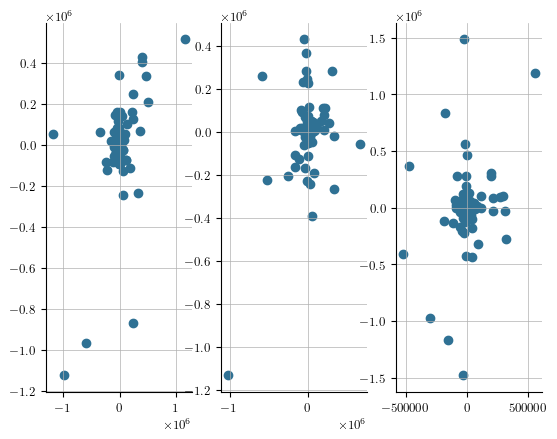

In [191]:
fig, axs = plt.subplots(ncols=fb_net_migration.shape[1])
for idx, year in enumerate(fb_net_migration.coords["Year"].data):
    axs[idx].scatter(1000 * UN_data["Net Number of Migrants (thousands)"].sel({"Year": year, "Country ISO": fb_net_migration.coords["Country ISO"].data}), fb_net_migration.sel({"Year": year}))

In [198]:
NZ_data = xr.load_dataset("../../data/Migration/NZL_data.nc")

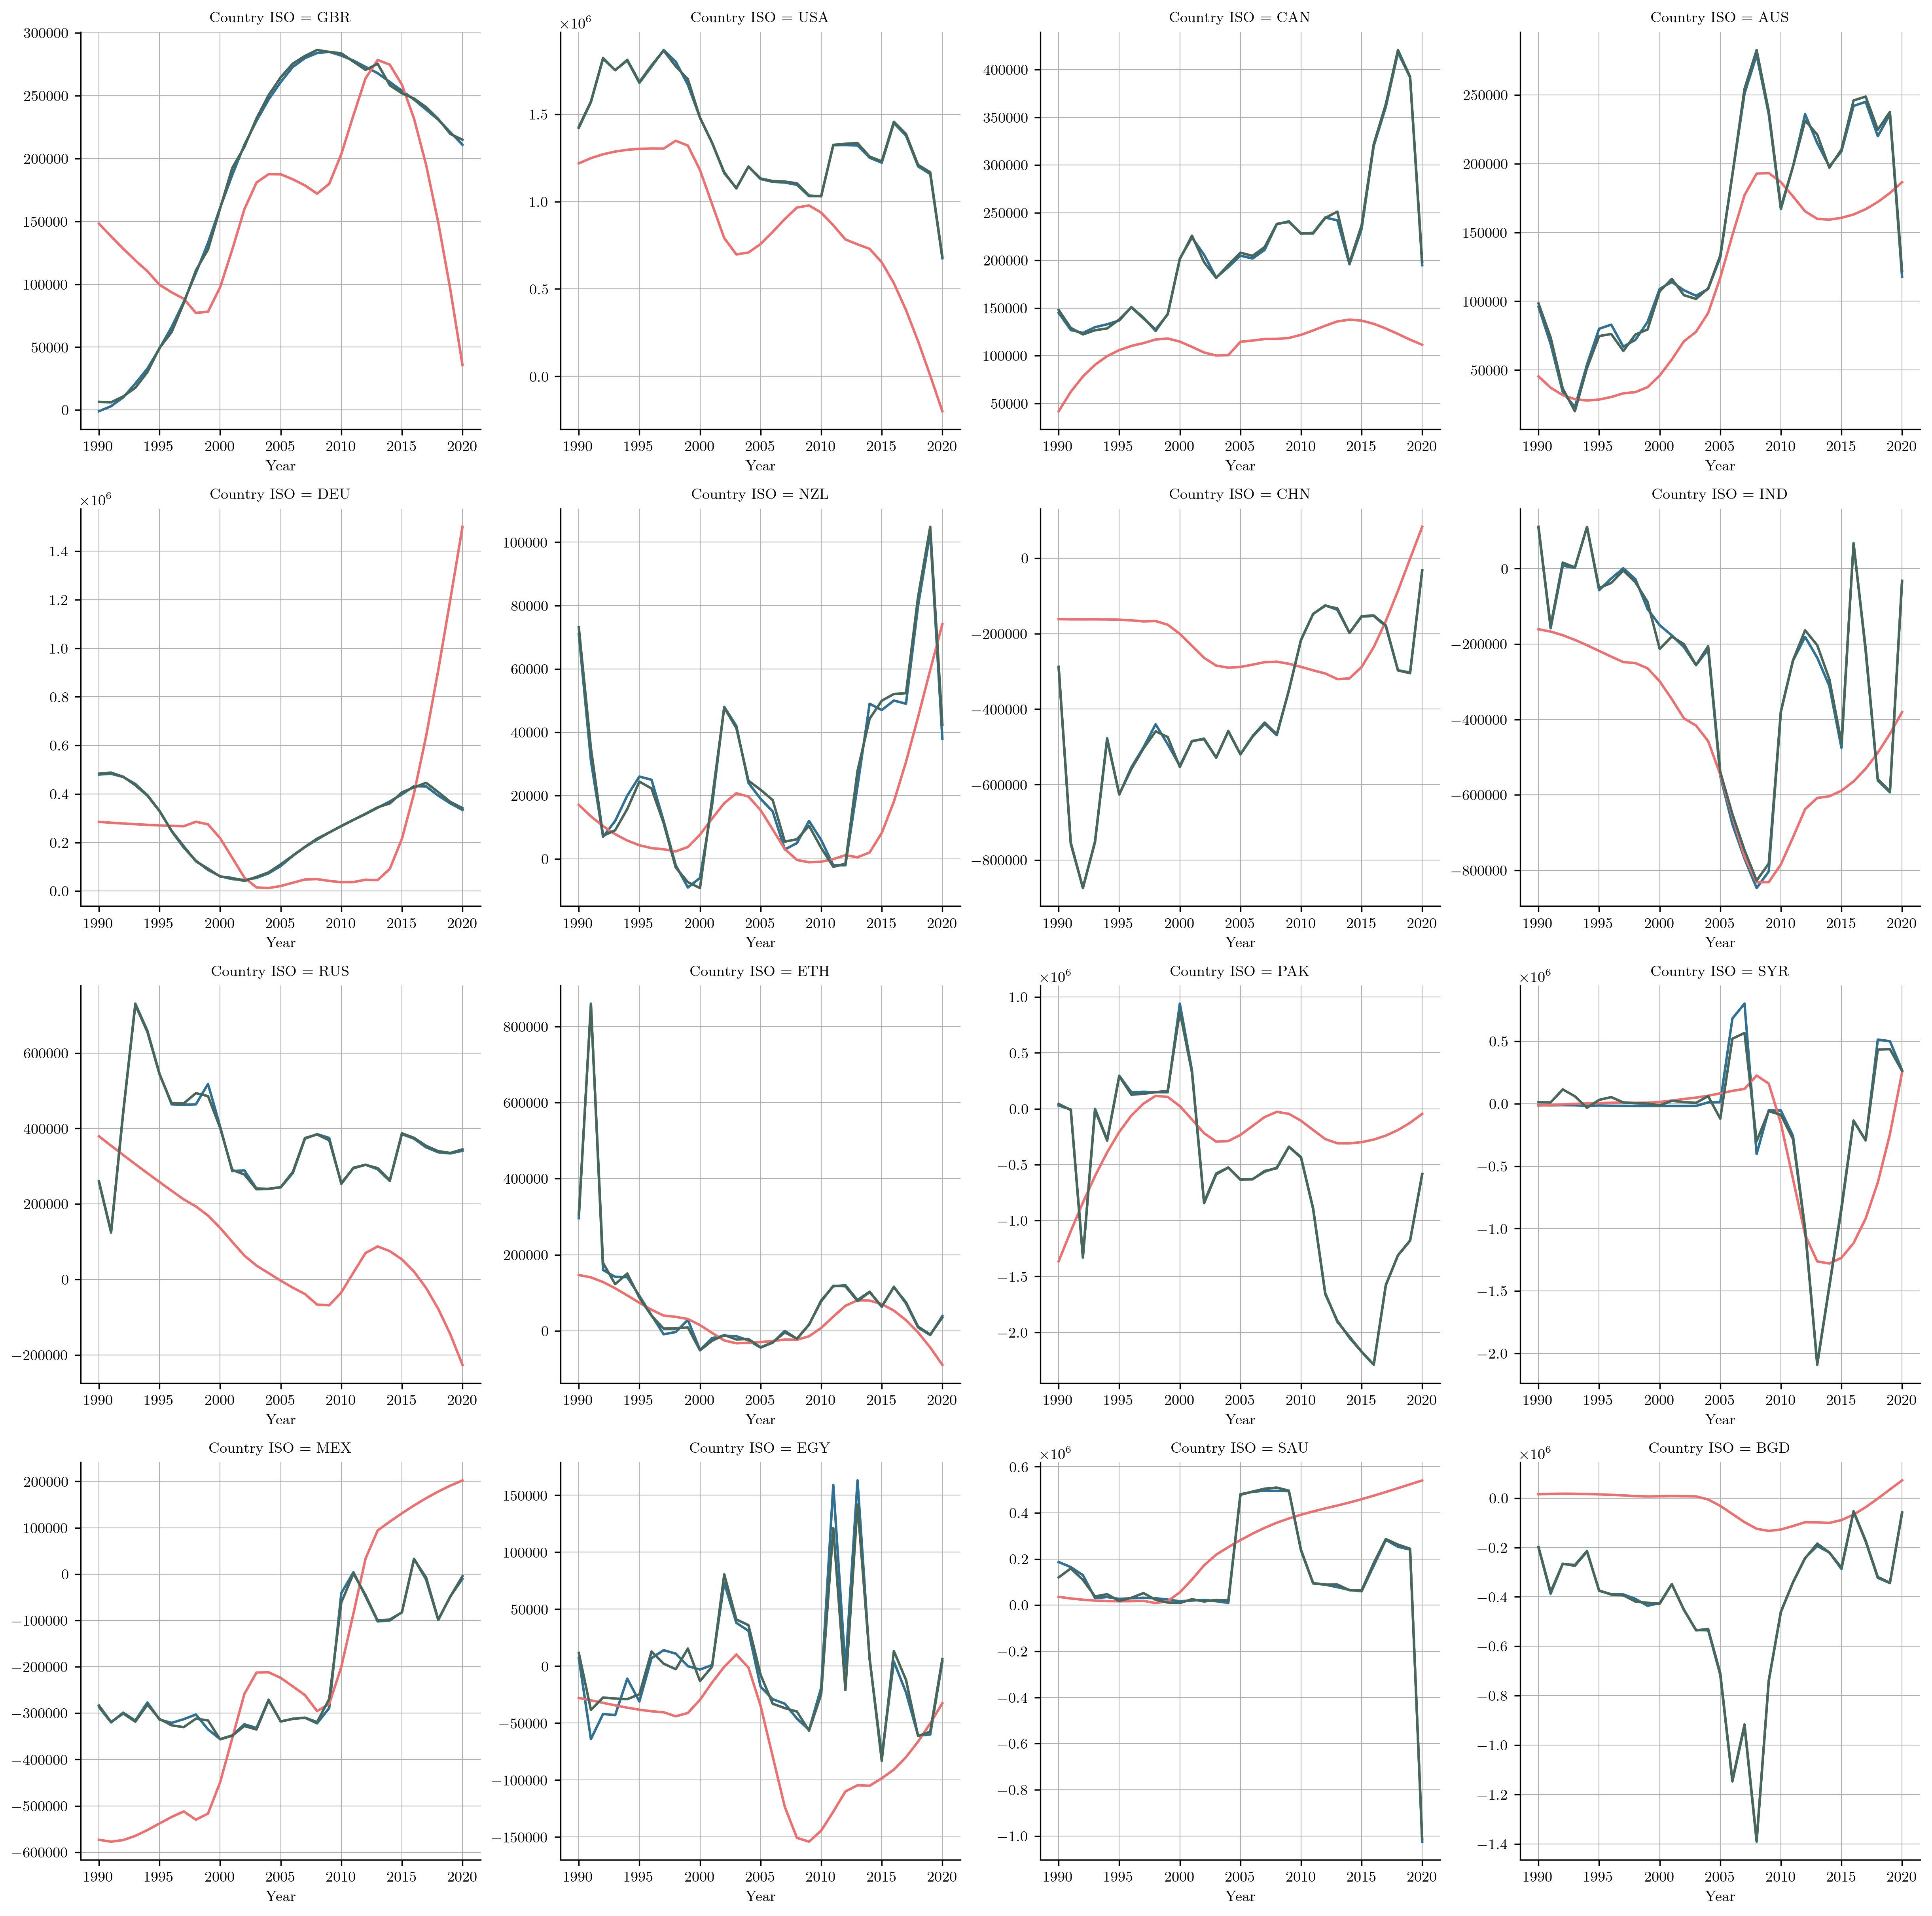

In [277]:
# Plot some predicted net migration values and compare with UN data
fig, axs = plt.subplots(ncols=4, nrows=4, figsize=(20, 20))
for idx, c in enumerate(["GBR", "USA", "CAN", "AUS", "DEU", "NZL", "CHN", "IND", "RUS", "ETH", "PAK", "SYR", "MEX", "EGY", "SAU", "BGD"]):
    (1000 * UN_data["Net Number of Migrants (thousands)"].sel({"Country ISO": c, "Year": range(1990, 2021)})).plot.line(ax=axs.flatten()[idx], label='UN net migration')
    (flow_estimate.sum("Origin ISO").rename({"Destination ISO": "Country ISO"}) - flow_estimate.sum("Destination ISO").rename({"Origin ISO": "Country ISO"})).sel({"Country ISO": c}).plot.line(ax=axs.flatten()[idx], label='Estimate')
    predicted_net_migration.sel({"Country ISO": c}).plot.line(ax=axs.flatten()[idx], label='Prediction')
# (NZ_data["arrivals"].sum("Country ISO") - NZ_data["departures"].sum("Country ISO")).sel({"Year": range(1990, 2020)}).plot.line(ax=ax, label='NZ data')
# ax.legend()